In [1]:
import sys
from pathlib import Path

# Add the src folder to the Python path
sys.path.append(str(Path.cwd().parent / "src"))

from bau_optimizer import EnhancedBAUOptimizer, BAUVisualizer, ReportGenerator

In [2]:
"""Run basic optimization example."""
# Initialize optimizer
optimizer = EnhancedBAUOptimizer()

In [3]:
# Generate and display current schedule
current_schedule = optimizer.generate_current_schedule()
print("Current Schedule:")
print(current_schedule)

Current Schedule:
                           1     2    3    4     5    6     7     8    9   \
omr_jupiter               0.0  0.75  0.0  0.0  0.00  0.0  0.00  0.75  0.0   
omr_wildfire_damage       0.0  0.75  0.0  0.0  0.00  0.0  0.00  0.75  0.0   
omr_physical_risk_damage  0.0  0.00  0.0  0.0  0.75  0.0  0.00  0.00  0.0   
omr_scorecard             0.0  0.00  0.0  0.0  0.00  0.0  0.00  0.00  0.0   
omr_first_street          0.0  0.00  0.0  0.0  0.00  0.0  0.75  0.00  0.0   
omr_ice                   0.0  0.00  0.0  0.0  0.00  0.0  0.00  0.00  0.0   

                           10    11   12  
omr_jupiter               0.0  0.00  0.0  
omr_wildfire_damage       0.0  0.00  0.0  
omr_physical_risk_damage  0.0  0.75  0.0  
omr_scorecard             0.0  0.75  0.0  
omr_first_street          0.0  0.00  0.0  
omr_ice                   0.0  0.75  0.0  


In [4]:
# Run optimization
optimized_schedule, changes = optimizer.optimize_schedule()
print("\nOptimized Schedule:")
print(optimized_schedule)


Optimized Schedule:
                            1     2    3    4     5     6     7     8     9   \
omr_jupiter               0.75  0.00  0.0  0.0  0.00  0.75  0.00  0.00  0.00   
omr_wildfire_damage       0.00  0.75  0.0  0.0  0.00  0.00  0.00  0.75  0.00   
omr_physical_risk_damage  0.00  0.00  0.0  0.0  0.75  0.00  0.00  0.00  0.75   
omr_scorecard             0.00  0.00  0.0  0.0  0.00  0.00  0.00  0.00  0.00   
omr_first_street          0.00  0.00  0.0  0.0  0.00  0.00  0.75  0.00  0.00   
omr_ice                   0.00  0.00  0.0  0.0  0.00  0.00  0.00  0.00  0.00   

                           10    11   12  
omr_jupiter               0.0  0.00  0.0  
omr_wildfire_damage       0.0  0.00  0.0  
omr_physical_risk_damage  0.0  0.00  0.0  
omr_scorecard             0.0  0.75  0.0  
omr_first_street          0.0  0.00  0.0  
omr_ice                   0.0  0.75  0.0  


In [5]:
# Display changes made with detailed information
print(f"\nChanges Made ({len(changes)}):")
for change in changes:
    orig_start = change.get('original_start_month', 'N/A')
    orig_end = change.get('original_end_month', 'N/A') 
    new_start = change.get('new_start_month', 'N/A')
    new_end = change.get('new_end_month', 'N/A')
    
    print(f"  {change['activity']}:")
    print(f"    Moved: Month {change['from_month']} → {change['to_month']}")
    print(f"    Original span: {orig_start} to {orig_end}")
    print(f"    New span: {new_start} to {new_end}")
    print(f"    Reason: {change['reason']}")
    print()


Changes Made (3):
  omr_jupiter:
    Moved: Month 8 → 6
    Original span: 2 to 8
    New span: 2 to 6
    Reason: Resolved model_ops shortage in Aug

  omr_jupiter:
    Moved: Month 2 → 1
    Original span: 2 to 8
    New span: 1 to 6
    Reason: Resolved model_ops shortage in Feb

  omr_physical_risk_damage:
    Moved: Month 11 → 9
    Original span: 5 to 11
    New span: 5 to 9
    Reason: Resolved model_ops shortage in Nov



Creating current schedule visualization...


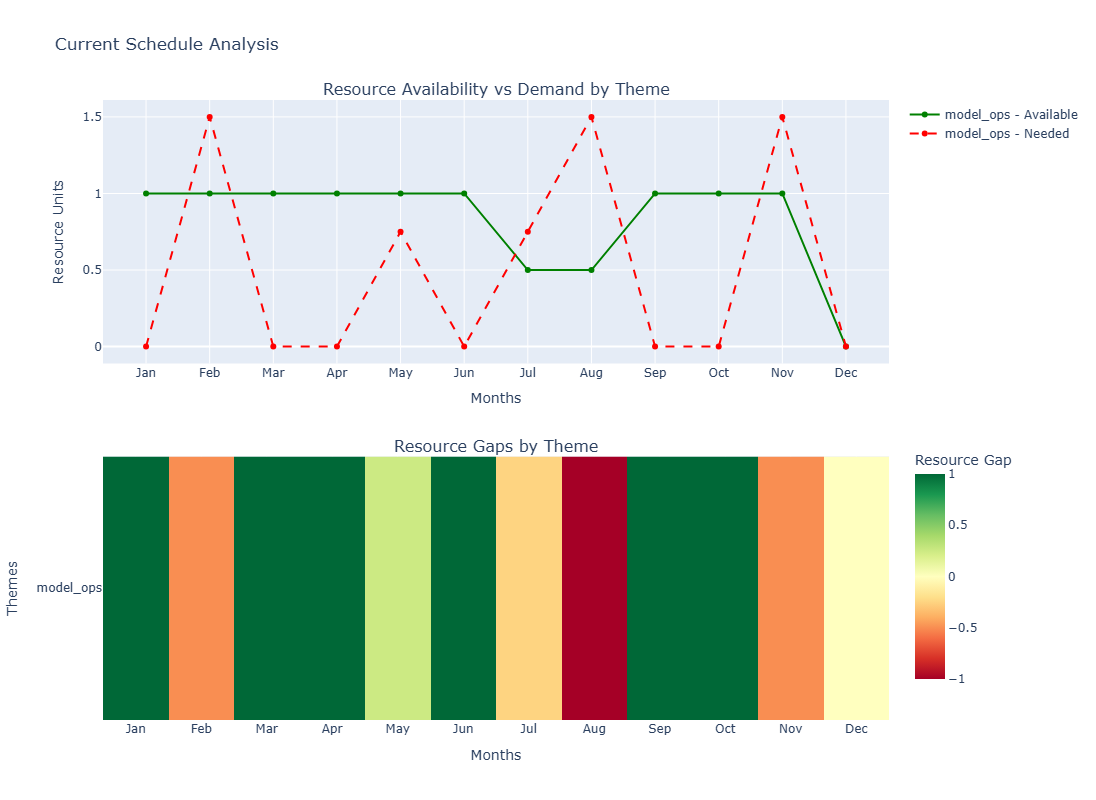

Creating optimized schedule visualization...


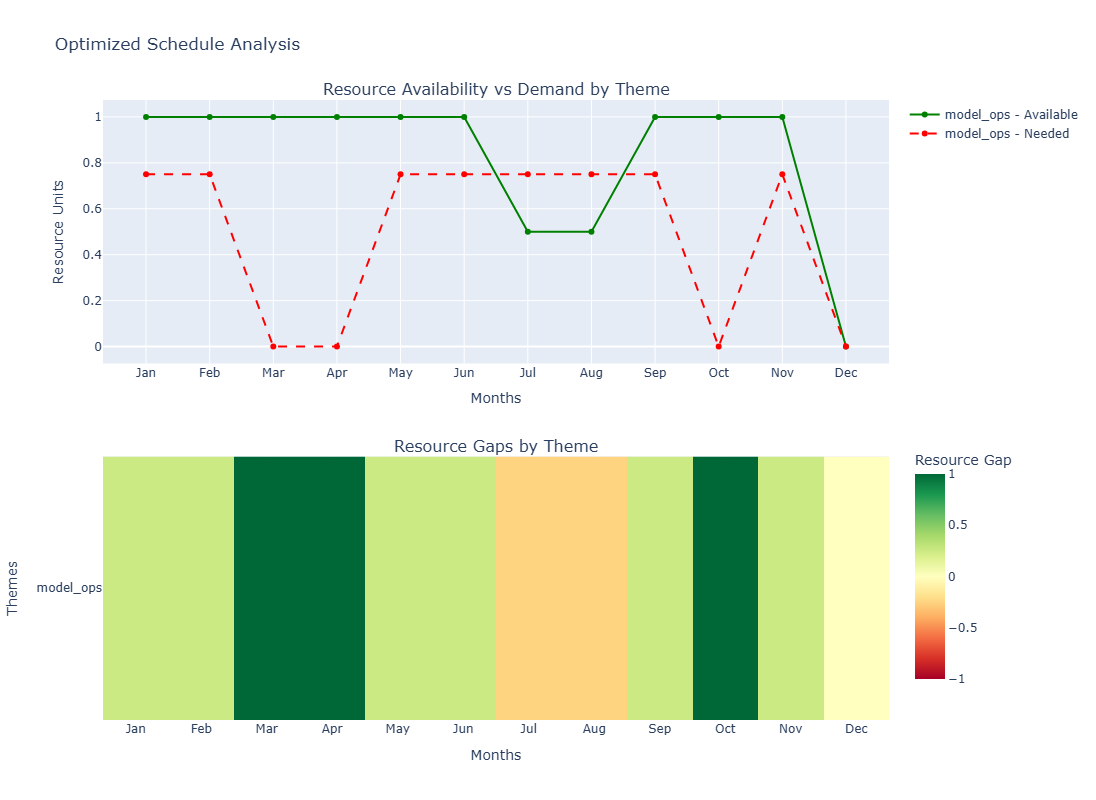

Creating comprehensive dashboard...


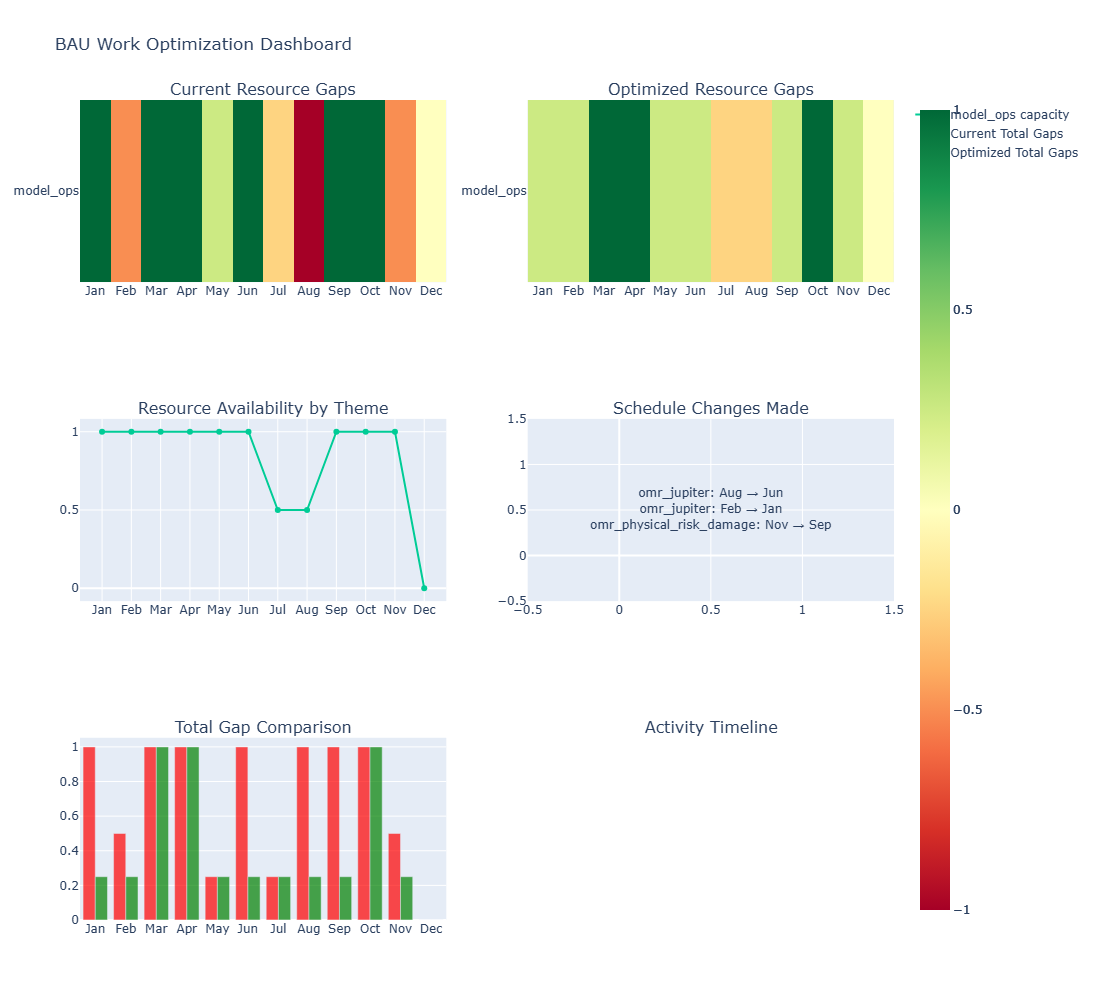

In [6]:
# Generate individual schedule visualizations
visualizer = BAUVisualizer(optimizer)

# Visualize current schedule
print("Creating current schedule visualization...")
current_fig = visualizer.visualize_schedule(current_schedule, "Current Schedule Analysis")
current_fig.show()

# Visualize optimized schedule  
print("Creating optimized schedule visualization...")
optimized_fig = visualizer.visualize_schedule(optimized_schedule, "Optimized Schedule Analysis")
optimized_fig.show()

# Generate comprehensive dashboard
print("Creating comprehensive dashboard...")
dashboard_fig = visualizer.create_comprehensive_dashboard()
dashboard_fig.show()

In [7]:
# Generate report
report_gen = ReportGenerator(optimizer)
summary = report_gen.generate_summary_report()
print(f"\nSummary: {summary['improvement_percent']:.1f}% improvement")


Summary: 41.2% improvement


## New Visualization Features

The updated BAU optimizer now includes:

1. **Individual Schedule Visualization**: Each schedule can be visualized with:
   - Line plot showing available resources (green) vs needed resources (red) by theme
   - Heatmap showing resource gaps by theme and month
   
2. **Enhanced Change Tracking**: Changes now include:
   - Original start and end dates of activities
   - New start and end dates after optimization
   - Detailed reasoning for each change

3. **Comprehensive Dashboard**: Combines multiple visualizations for complete analysis